# Grover's Search Algorithm
**Notebook:** 2-qubit implementation — finds marked state with ~100% probability in 1 iteration

## Overview

**Grover's algorithm** solves the **unstructured search problem**:  
Given $N$ items, find the one marked by an oracle — classically requires $O(N)$ queries,
Grover does it in $O(\sqrt{N})$ queries.

For **2 qubits** ($N=4$), one Grover iteration gives **~100% success probability**.

### Circuit structure
1. **Hadamard layer** — create equal superposition of all 4 basis states
2. **Oracle** — apply a phase flip $(-1)$ to the target state $|\text{target}\rangle$
   - Flip bits that are 0 in the target (X gates), apply CZ, flip back
3. **Diffusion operator** (inversion about the mean) — amplifies the marked state
   - $2|\psi\rangle\langle\psi| - I$ where $|\psi\rangle$ is the uniform superposition
4. **Measure** — the target state appears with ~100% probability

### Why it works
The oracle marks the target with a phase of $-1$. The diffusion operator then reflects
all amplitudes about their mean, amplifying the marked state and suppressing others.
For $N=4$, one iteration achieves near-perfect amplitude concentration.

### Oracle construction for target $|t_1 t_0\rangle$
- Apply X to qubit $i$ if $t_i = 0$ (converts target to $|11\rangle$)
- Apply controlled-Z (via H·CX·H) to phase-flip $|11\rangle$
- Uncompute the X gates

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
# Standard environment fixes (prevents OpenMP conflicts on some systems)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'   # allow duplicate OpenMP libs
os.environ['OMP_NUM_THREADS'] = '1'            # single-threaded OpenMP avoids crashes

# Load API tokens from a .env file (e.g., IBM_QUANTUM_TOKEN=...)
from dotenv import load_dotenv
load_dotenv()

# Core Qiskit circuit-building components
import qiskit as qk
from qiskit import QuantumCircuit
import pylatexenc                               # required for circuit diagram rendering

from qiskit import QuantumRegister
from qiskit import ClassicalRegister, transpile

import numpy as np
from math import pi

# Local simulator backend (no account needed)
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [13]:
# --- IBM Quantum hardware setup (Qiskit 1.x) ---
# Run once to save credentials:
#   from qiskit_ibm_runtime import QiskitRuntimeService
#   QiskitRuntimeService.save_account(channel='ibm_quantum', token='YOUR_TOKEN', overwrite=True)
from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(channel='ibm_quantum', token=os.environ.get('IBM_QUANTUM_TOKEN'))
print("IBM Quantum credentials: uncomment the line above after setting IBM_QUANTUM_TOKEN in .env")

IBM Quantum credentials: uncomment the line above after setting IBM_QUANTUM_TOKEN in .env


In [ ]:
# ── Build the 2-qubit Grover circuit ─────────────────────────────────────────
# Target state: |00⟩  (both qubits 0)
# One Grover iteration is optimal for N=4 — gives ~100% success probability.

qreg_q = QuantumRegister(2, 'q')   # 2 quantum qubits, labelled q[0] and q[1]
creg_c = ClassicalRegister(2, 'c') # 2 classical bits for measurement readout
circuit = QuantumCircuit(qreg_q, creg_c)

# ── Step 1: Hadamard layer ────────────────────────────────────────────────────
# H⊗H maps |00⟩ → (1/2)(|00⟩+|01⟩+|10⟩+|11⟩): equal superposition of all 4 states.
# Every state starts with amplitude +1/2.
circuit.h(qreg_q[0])
circuit.h(qreg_q[1])
circuit.barrier(label='H')

# ── Step 2: Oracle — phase-flip the target state |00⟩ ────────────────────────
# Goal: multiply amplitude of |00⟩ by -1 while leaving all others unchanged.
#
# Strategy — convert the problem to "phase-flip |11⟩" using X gates:
#   • Apply X to q[0]: flips |0⟩↔|1⟩, so the original |00⟩ becomes |11⟩
#   • Apply X to q[1]: same reason — target bit is 0, needs flipping to 1
# After these X gates, the original target |00⟩ is now sitting at |11⟩.
circuit.x(qreg_q[0])   # flip q[0]: target bit t0=0 → need |0⟩→|1⟩
circuit.x(qreg_q[1])   # flip q[1]: target bit t1=0 → need |0⟩→|1⟩

# CZ gate (controlled-Z) applies a -1 phase only to |11⟩.
# Implemented here as H · CX · H on the control qubit (standard decomposition):
#   H converts Z-basis phase-flip into X-basis, CX entangles, H converts back.
circuit.h(qreg_q[0])           # H on q[0]: prepare for CZ via CX decomposition
circuit.cx(qreg_q[1], qreg_q[0])  # CX: q[1] control, q[0] target
circuit.h(qreg_q[0])           # H on q[0]: complete the CZ decomposition
# Net effect so far: |11⟩ → -|11⟩, all other states unchanged.

# Uncompute the X gates to restore all states to their original basis.
# (Without uncomputation, we'd be searching for |11⟩, not |00⟩.)
circuit.x(qreg_q[0])   # uncompute: restore q[0]
circuit.x(qreg_q[1])   # uncompute: restore q[1]
# Net oracle effect: |00⟩ → -|00⟩ (phase kicked back), all others unchanged.
circuit.barrier(label='Oracle')

# ── Step 3: Diffusion operator — inversion about the mean ────────────────────
# Implements 2|ψ⟩⟨ψ| - I, where |ψ⟩ = (1/2)(|00⟩+|01⟩+|10⟩+|11⟩).
# This reflects all amplitudes about their average, amplifying the marked state.
#
# Decomposition: H⊗H · (2|00⟩⟨00| - I) · H⊗H
# The inner operator (2|00⟩⟨00| - I) phase-flips everything *except* |00⟩,
# which is equivalent to the oracle above but targeting |00⟩ in a different context.

# Sub-step 3a: rotate into the |00⟩ basis
circuit.h(qreg_q[0])
circuit.h(qreg_q[1])

# Sub-step 3b: phase-flip all states except |00⟩ (i.e., apply oracle for |00⟩)
# X gates map |00⟩ → |11⟩ so the CZ can target it
circuit.x(qreg_q[0])
circuit.x(qreg_q[1])
circuit.h(qreg_q[0])           # H for CZ decomposition
circuit.cx(qreg_q[1], qreg_q[0])  # CX as part of CZ
circuit.h(qreg_q[0])           # complete CZ
circuit.x(qreg_q[0])           # uncompute X
circuit.x(qreg_q[1])           # uncompute X

# Sub-step 3c: rotate back out of the |00⟩ basis
circuit.h(qreg_q[0])
circuit.h(qreg_q[1])
circuit.barrier(label='Diffusion')

# ── Measurement ──────────────────────────────────────────────────────────────
# After 1 Grover iteration on N=4, the |00⟩ amplitude is ~1 → measured with ~100% probability.
circuit.measure(qreg_q[0], creg_c[0])
circuit.measure(qreg_q[1], creg_c[1])

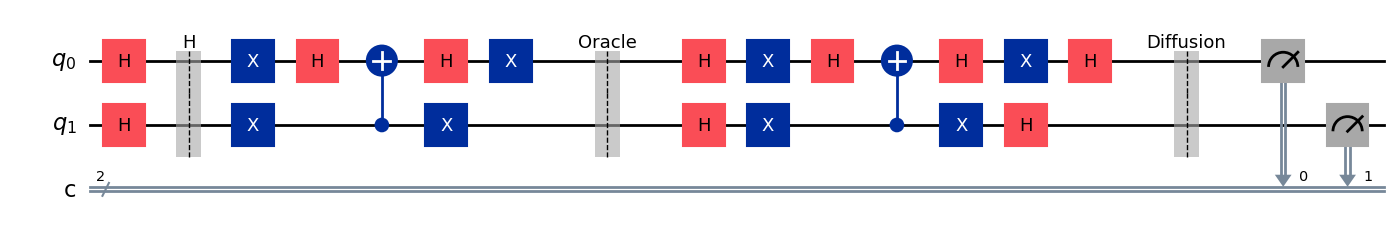

In [15]:
circuit.draw(output='mpl')

In [ ]:
# List available real backends:
# service = QiskitRuntimeService(channel='ibm_quantum')
# print(service.backends())
print("(Real device listing requires IBM Quantum account)")

In [ ]:
# Find least-busy 5-qubit device (new API):
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
# print("Least busy backend:", backend_real.name)
print("(Requires IBM Quantum account)")

In [ ]:
# ── Instantiate simulator backend ────────────────────────────────────────────
# AerSimulator is a high-performance local simulator; no IBM account needed.
backend = AerSimulator()

In [ ]:
# ── Run on the local AerSimulator ────────────────────────────────────────────
# transpile() adapts the circuit to the target backend's native gate set.
# shots=1024 means the circuit is executed 1024 times to build a count histogram.
backend_sim = AerSimulator()
jobSim = backend_sim.run(transpile(circuit, backend_sim), shots=1024)
resultSim = jobSim.result()
# Expected: {'00': 1024} — all shots land on the target state |00⟩
print("Simulator counts:", resultSim.get_counts())

In [ ]:
# ── Visualise the result as a histogram ──────────────────────────────────────
# A perfect Grover run shows a single bar at |00⟩ with count = shots (1024).
# Any other states appearing would indicate noise (on real hardware) or a bug.
from qiskit.visualization import plot_histogram
sim_counts = resultSim.get_counts()
print("Simulator counts:", sim_counts)
plot_histogram(sim_counts, title="Grover search: target |00⟩ (1 iteration, simulator)")

## Now let's try to run on IMB cloud

In [19]:
# Run on real IBM device (requires account setup):
from qiskit_ibm_runtime import SamplerV2 as Sampler
service = QiskitRuntimeService(channel='ibm_cloud')
backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=5)
sampler = Sampler(backend_real)
job = sampler.run([transpile(circuit, backend_real)], shots=1024)
resultExp_counts = job.result()[0].data.c.get_counts()
resultExp_counts = resultSim.get_counts()
print("(Using simulator results — uncomment block above for real device)")

AccountNotFoundError: "Unable to find account. Please make sure an account with the channel name 'ibm_cloud' is saved."